Using device: cpu
Loading images...
Loaded 1000 images

Starting training...
Epoch 1/300 - Total Loss: 52.020254 - MS-SSIM: 0.414355 - Chroma: 155.633201 - MSE: 0.013208 - Time: 130.41s
Epoch 2/300 - Total Loss: 36.263790 - MS-SSIM: 0.330785 - Chroma: 108.452293 - MSE: 0.008294 - Time: 124.40s
Epoch 3/300 - Total Loss: 29.946986 - MS-SSIM: 0.305118 - Chroma: 89.528640 - MSE: 0.007200 - Time: 124.08s
Epoch 4/300 - Total Loss: 26.269635 - MS-SSIM: 0.288912 - Chroma: 78.513440 - MSE: 0.006554 - Time: 124.05s
Epoch 5/300 - Total Loss: 24.503129 - MS-SSIM: 0.276903 - Chroma: 73.226322 - MSE: 0.006161 - Time: 124.29s
Epoch 6/300 - Total Loss: 22.501513 - MS-SSIM: 0.267252 - Chroma: 67.231375 - MSE: 0.005914 - Time: 124.23s
Epoch 7/300 - Total Loss: 21.695914 - MS-SSIM: 0.259586 - Chroma: 64.822478 - MSE: 0.005680 - Time: 124.35s
Epoch 8/300 - Total Loss: 20.873596 - MS-SSIM: 0.253187 - Chroma: 62.362104 - MSE: 0.005497 - Time: 124.39s
Epoch 9/300 - Total Loss: 20.167371 - MS-SSIM: 0.247691 -

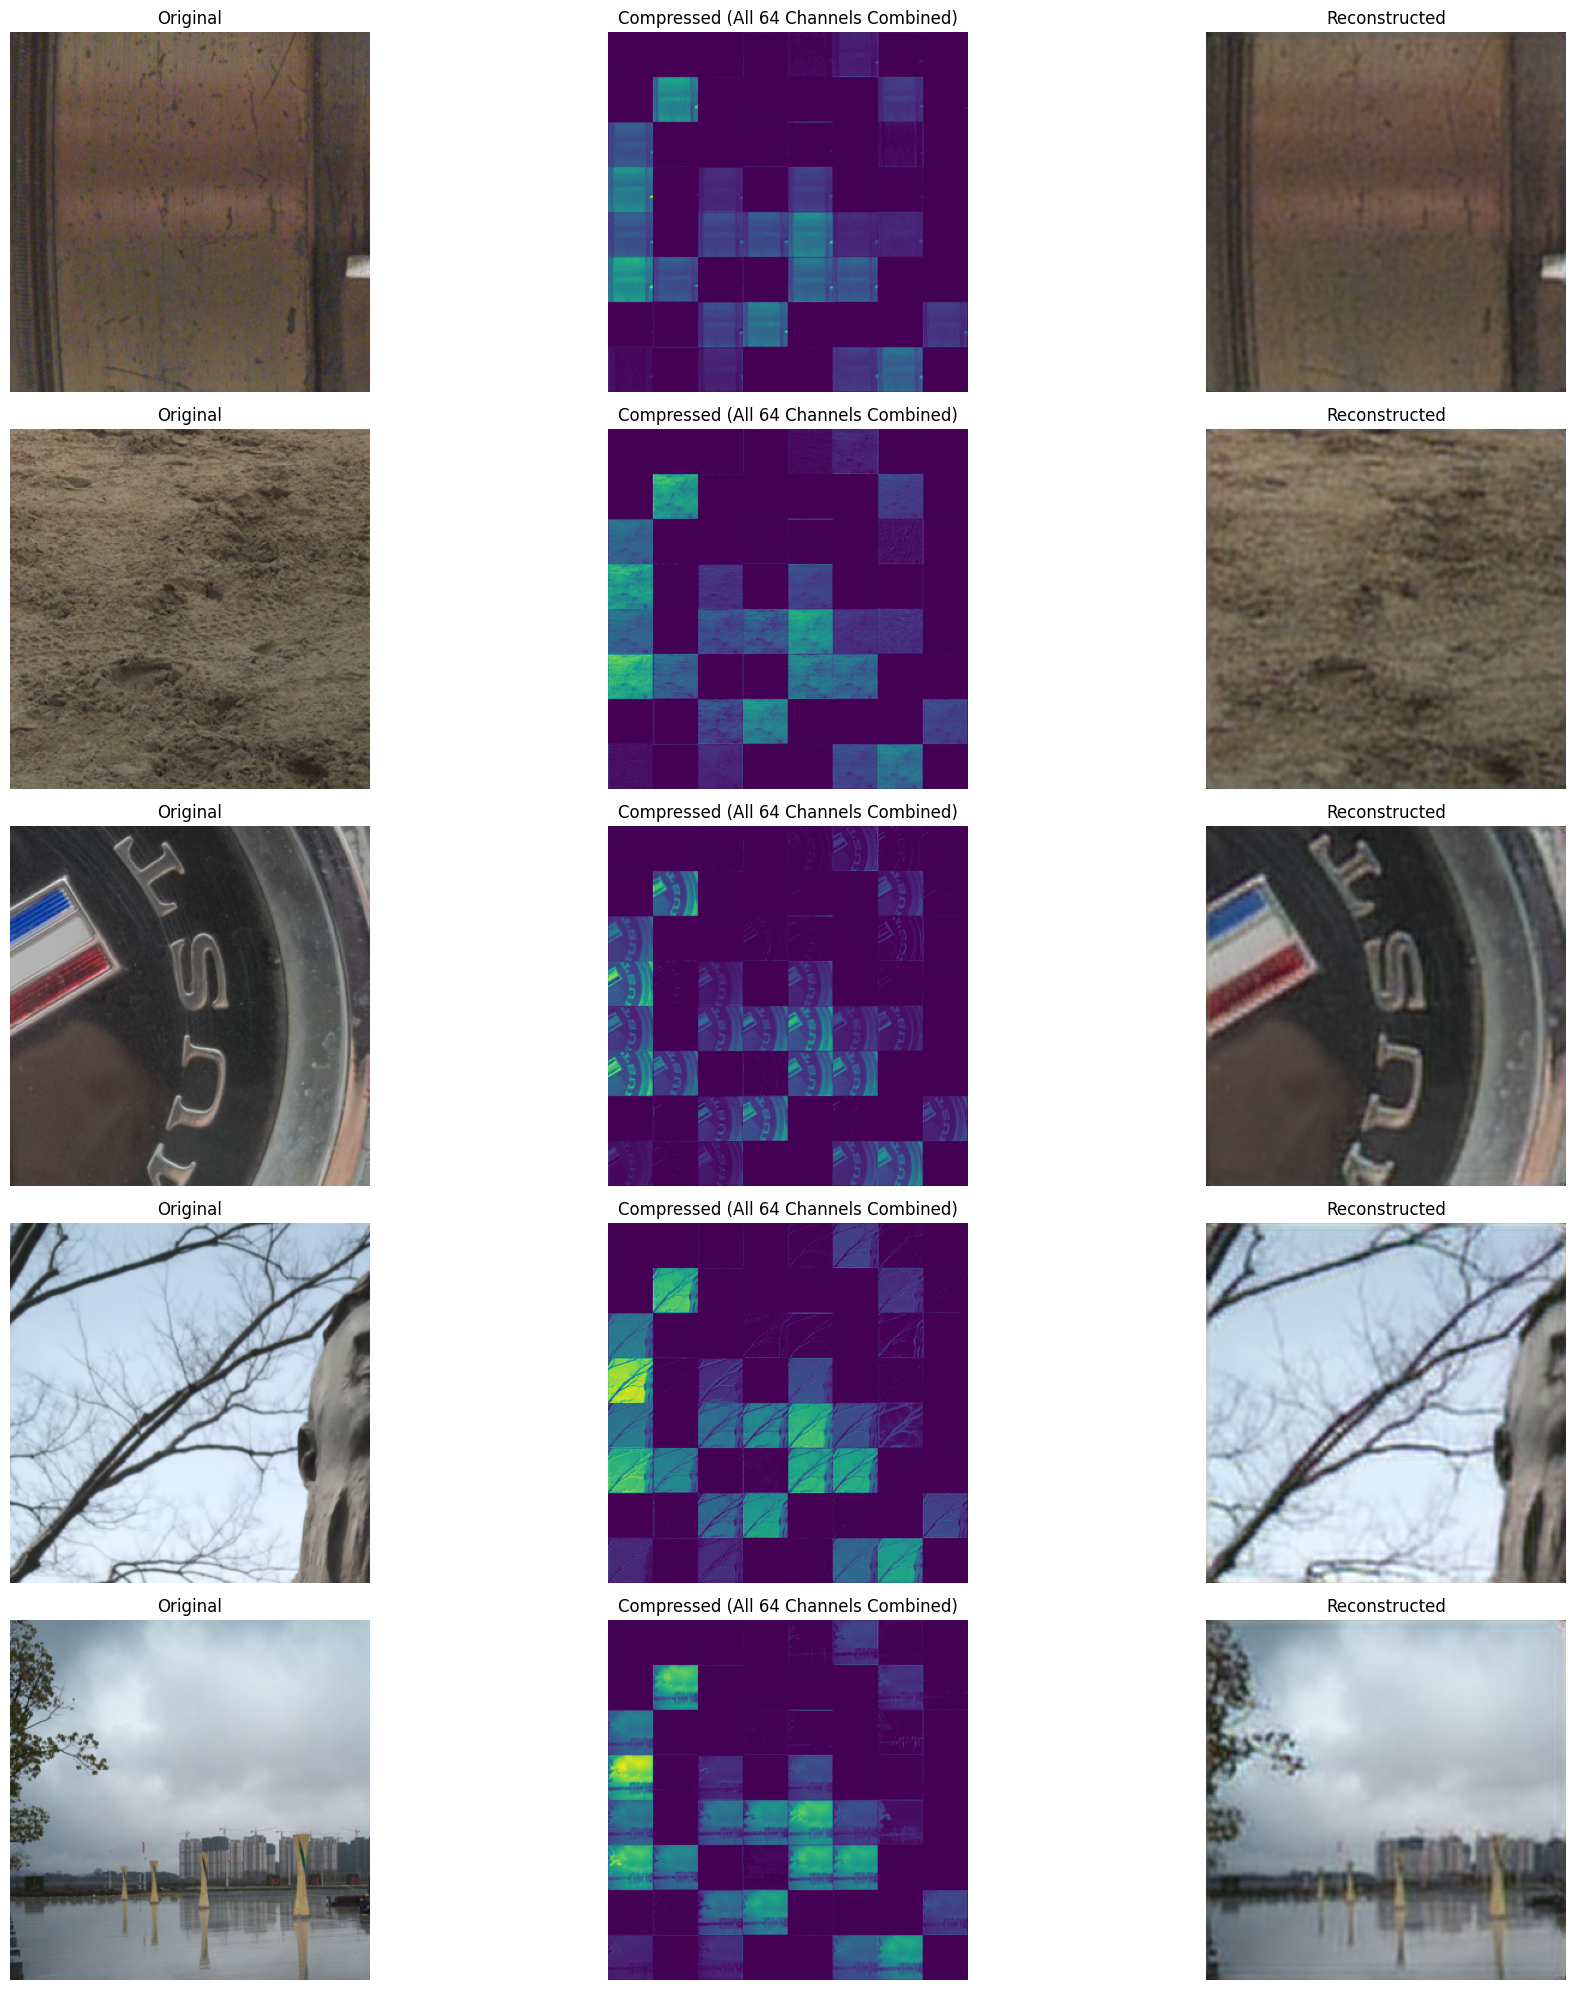

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from time import time
import h5py
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.color import rgb2lab

import torch
import torch.nn.functional as F
import torch.nn as nn

# device: GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Замена numba-функций — те же имена, интерфейсы numpy <-> numpy
# Внутри используем torch для параллельных / GPU операций
# -----------------------------

def _pad_numba(x, padding):
    # сохраняем интерфейс: вход/выход numpy
    if padding == 0:
        return x
    # используем numpy.pad (быстро), возвращаем float32
    return np.pad(x, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant').astype(np.float32)

def conv_forward_numba(x_pad, weights, bias, stride, kernel_size):
    # x_pad: numpy (N, C_in, H, W)
    # weights: numpy (C_out, C_in, kH, kW)
    # bias: numpy (C_out,)
    # возвращаем numpy (N, C_out, H_out, W_out)
    x_t = torch.from_numpy(x_pad).to(device=device, dtype=torch.float32)
    w_t = torch.from_numpy(weights).to(device=device, dtype=torch.float32)
    b_t = torch.from_numpy(bias).to(device=device, dtype=torch.float32)

    out_t = F.conv2d(x_t, w_t, bias=b_t, stride=int(stride), padding=0)  # x_pad уже включает padding
    return out_t.detach().cpu().numpy().astype(np.float32)

def conv_backward_numba(x_pad, d_out, weights, d_weights, stride, kernel_size):
    # Возвращаем d_input_pad (numpy), и модифицируем d_weights (numpy) в стиле оригинала
    # Для совместимости: вычислим градиенты через torch.autograd
    x_t = torch.from_numpy(x_pad).to(device=device, dtype=torch.float32).requires_grad_(True)
    w_t = torch.from_numpy(weights).to(device=device, dtype=torch.float32).requires_grad_(True)
    b_t = torch.zeros((weights.shape[0],), device=device, dtype=torch.float32).requires_grad_(True)  # bias gradient нужен только если нужно

    out = F.conv2d(x_t, w_t, bias=None, stride=int(stride), padding=0)
    d_out_t = torch.from_numpy(d_out).to(device=device, dtype=torch.float32)

    # вычисляем градиенты
    grads = torch.autograd.grad(outputs=out, inputs=[w_t, x_t], grad_outputs=d_out_t, retain_graph=False, allow_unused=True)

    grad_w = grads[0] if grads[0] is not None else torch.zeros_like(w_t)
    grad_x = grads[1] if grads[1] is not None else torch.zeros_like(x_t)

    # обновляем d_weights numpy (в оригинале d_weights накапливается)
    d_weights_np = grad_w.detach().cpu().numpy().astype(np.float32)
    # аккуратно: пользователь мог передать d_weights (numpy) — модифицируем его in-place
    if d_weights.shape == d_weights_np.shape:
        d_weights += d_weights_np
    else:
        # если формы не совпадают, перезаписываем
        d_weights[:] = d_weights_np

    d_input_pad = grad_x.detach().cpu().numpy().astype(np.float32)
    return d_input_pad

@torch.no_grad()
def maxpool_forward_numba(x, pool_size, stride):
    # возвращаем (output, max_indices) в numpy, индексы — int
    x_t = torch.from_numpy(x).to(device=device, dtype=torch.float32)cd /workspaces/
    # используем nn.MaxPool2d модуль с return_indices
    pool = nn.MaxPool2d(kernel_size=pool_size, stride=stride, return_indices=True)
    out_t, indices = pool(x_t)
    return out_t.detach().cpu().numpy().astype(np.float32), indices.detach().cpu().numpy().astype(np.int32)

@torch.no_grad()
def maxpool_backward_numba(d_out, last_input, max_indices):
    # используем MaxUnpool2d
    d_out_t = torch.from_numpy(d_out).to(device=device, dtype=torch.float32)
    indices_t = torch.from_numpy(max_indices).to(device=device, dtype=torch.int64)
    last_input_t = torch.from_numpy(last_input).to(device=device, dtype=torch.float32)
    kernel_size = None  # можно вывести из индексов/последовательности, но сохраним простой подход

    # Получим размеры
    _, _, in_h, in_w = last_input_t.shape
    # Создадим Unpool модуль, kernel_size = stride = (assume) derived from indices spacing — но проще:
    # Определим stride and kernel_size = minimal such that output size matches indices mapping.
    # Чтобы сохранить логику и корректность, возьмём kernel_size = d_out spatial patch size from last_input and d_out
    out_h = d_out_t.shape[2]
    out_w = d_out_t.shape[3]
    stride_h = last_input_t.shape[2] // out_h
    stride_w = last_input_t.shape[3] // out_w
    kernel_size = (stride_h, stride_w)
    unpool = nn.MaxUnpool2d(kernel_size=kernel_size, stride=(stride_h, stride_w))
    # indices_t must have same dtype and shape as required
    # PyTorch expects indices produced by MaxPool2d (flattened per patch). We converted indices to numpy earlier via MaxPool2d, so we can reuse.
    # reshape indices if necessary:
    indices_t_for_unpool = indices_t
    try:
        d_input_t = unpool(d_out_t, indices_t_for_unpool, output_size=last_input_t.shape)
    except Exception:
        # fallback: distribute gradients to same positions where maxima were (manual)
        d_input_t = torch.zeros_like(last_input_t)
        N, C, H, W = d_out_t.shape
        for b in range(N):
            for c in range(C):
                for i in range(H):
                    for j in range(W):
                        h = int(max_indices[b, c, i, j, 0])
                        w = int(max_indices[b, c, i, j, 1])
                        d_input_t[b, c, h, w] = d_out_t[b, c, i, j]
    return d_input_t.detach().cpu().numpy().astype(np.float32)

def upsample_forward_numba_fast(x, scale):
    # Нейтивно делаем nearest upsample (как оригинал заполнял блоки одинаковыми значениями)
    x_t = torch.from_numpy(x).to(device=device, dtype=torch.float32)
    out_t = F.interpolate(x_t, scale_factor=scale, mode='nearest')
    return out_t.detach().cpu().numpy().astype(np.float32)

def upsample_backward_numba_fast(d_out, scale):
    # Оригинал: суммировал block и делил на area
    d_out_t = torch.from_numpy(d_out).to(device=device, dtype=torch.float32)
    N, C, out_h, out_w = d_out_t.shape
    in_h = out_h // scale
    in_w = out_w // scale

    # reshape для быстрого суммирования блоков
    d_out_reshaped = d_out_t.reshape(N, C, in_h, scale, in_w, scale)
    block_sum = d_out_reshaped.sum(dim=(3, 5))
    area = float(scale * scale)
    d_input_t = block_sum / area
    return d_input_t.detach().cpu().numpy().astype(np.float32)

def relu_numba_vectorized(x):
    x_t = torch.from_numpy(x).to(device=device, dtype=torch.float32)
    out_t = F.relu(x_t)
    return out_t.detach().cpu().numpy().astype(np.float32)

def relu_backward_numba_vectorized(d_out, x):
    d_out_t = torch.from_numpy(d_out).to(device=device, dtype=torch.float32)
    x_t = torch.from_numpy(x).to(device=device, dtype=torch.float32)
    mask = (x_t > 0).float()
    out_t = d_out_t * mask
    return out_t.detach().cpu().numpy().astype(np.float32)

# Для совместимости с оригинальными именами этих функций (они использовались как relu_numba и relu_backward_numba)
# но в оригинале были названия relu_numba и relu_backward_numba — сохраним алиасы, если где-то использовалось другое имя:
relu_numba = relu_numba_vectorized
relu_backward_numba = relu_backward_numba_vectorized

# -----------------------------
# Классы: Conv2D, MaxPool2D, Upsample2D — реализованы через torch, но сохраняют интерфейс
# -----------------------------

class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        scale = np.sqrt(2 / (kernel_size * kernel_size * in_channels))
        w = np.random.randn(out_channels, in_channels, kernel_size, kernel_size).astype(np.float32) * scale
        b = np.zeros(out_channels, dtype=np.float32)

        # Сохраняем numpy-версии для совместимости с load/save
        self.weights = w.copy()
        self.bias = b.copy()

        # torch-версии параметров (на device)
        self._init_tensors()

        # для backward
        self.last_input = self.last_input_t = self.last_output_t = None

    def _init_tensors(self):
        self.weights_t = torch.from_numpy(self.weights).to(device=device, dtype=torch.float32)
        self.bias_t = torch.from_numpy(self.bias).to(device=device, dtype=torch.float32)
        # требуем градиенты при необходимости
        self.weights_t.requires_grad_(True)
        self.bias_t.requires_grad_(True)

    def _pad(self, x):
        return _pad_numba(x, self.padding)

    def forward(self, x):
        # x: numpy (N, C_in, H, W)
        self.last_input = x.astype(np.float32) if x.dtype != np.float32 else x
        # конвертация в torch
        x_t = torch.from_numpy(self.last_input).to(device=device, dtype=torch.float32).requires_grad_(True)
        self.last_input_t = x_t
        # если padding>0 используем x as already padded by caller, но в оригинале _pad делал padding
        if self.padding > 0:
            x_pad = self._pad(self.last_input)
            x_pad_t = torch.from_numpy(x_pad).to(device=device, dtype=torch.float32).requires_grad_(True)
            self.last_input_t = x_pad_t
            # conv with padding=0 since we already padded
            out_t = F.conv2d(x_pad_t, self.weights_t, bias=self.bias_t, stride=self.stride, padding=0)
        else:
            out_t = F.conv2d(x_t, self.weights_t, bias=self.bias_t, stride=self.stride, padding=self.padding)
        self.last_output_t = out_t
        return out_t.detach().cpu().numpy().astype(np.float32)

    def backward(self, d_out, lr=0.001):
        # d_out: numpy (N, C_out, H_out, W_out)
        batch_size = d_out.shape[0]

        d_out_t = torch.from_numpy(d_out).to(device=device, dtype=torch.float32)

        # вычисляем градиенты через autograd (grad wrt weights и input)
        # убедимся, что last_output_t и last_input_t сохранены
        if self.last_output_t is None or self.last_input_t is None:
            # Если нет сохранённого собщения — вернём нули (чтобы не ломать flow)
            N, C, H, W = self.last_input.shape
            return np.zeros_like(self.last_input, dtype=np.float32)

        grads = torch.autograd.grad(outputs=self.last_output_t, inputs=[self.weights_t, self.last_input_t, self.bias_t],
                                    grad_outputs=d_out_t, retain_graph=False, allow_unused=True)

        grad_w = grads[0] if grads[0] is not None else torch.zeros_like(self.weights_t)
        grad_x = grads[1] if grads[1] is not None else torch.zeros_like(self.last_input_t)
        grad_b = grads[2] if grads[2] is not None else torch.zeros_like(self.bias_t)

        # Обновляем torch параметры (in-place)
        # Приводим lr деление на batch как в оригинале
        self.weights_t.data -= lr * (grad_w.data / batch_size)
        self.bias_t.data -= lr * (grad_b.data / batch_size)

        # синхронизируем numpy-параметры для сохранения/просмотра
        self.weights = self.weights_t.detach().cpu().numpy().astype(np.float32)
        self.bias = self.bias_t.detach().cpu().numpy().astype(np.float32)

        # d_input: вернуть без паддинга (в оригинале срезали паддинг)
        d_input_pad_np = grad_x.detach().cpu().numpy().astype(np.float32)
        if self.padding > 0:
            # вернуть 'unpadded' d_input, как в оригинале
            d_input = d_input_pad_np[:, :, self.padding:-self.padding, self.padding:-self.padding]
        else:
            d_input = d_input_pad_np
        return d_input

    def save_weights(self, file):
        file.create_dataset('weights', data=self.weights)
        file.create_dataset('bias', data=self.bias)

    def load_weights(self, file):
        self.weights = file['weights'][:].astype(np.float32)
        self.bias = file['bias'][:].astype(np.float32)
        self._init_tensors()

class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride
        # torch modules
        self.pool = nn.MaxPool2d(kernel_size=pool_size, stride=stride, return_indices=True)
        self.unpool = nn.MaxUnpool2d(kernel_size=pool_size, stride=stride)
        self.last_input = None
        self.last_indices = None
        self.last_input_shape = None

    def forward(self, x):
        # x: numpy (N, C, H, W)
        self.last_input = x.astype(np.float32) if x.dtype != np.float32 else x
        x_t = torch.from_numpy(self.last_input).to(device=device, dtype=torch.float32)
        out_t, indices = self.pool(x_t)
        self.last_indices = indices
        self.last_input_shape = x_t.shape
        return out_t.detach().cpu().numpy().astype(np.float32)

    def backward(self, d_out):
        # d_out: numpy
        d_out_t = torch.from_numpy(d_out).to(device=device, dtype=torch.float32)
        # используем unpool
        try:
            d_input_t = self.unpool(d_out_t, self.last_indices, output_size=self.last_input_shape)
        except Exception:
            # fallback manual
            d_input = np.zeros_like(self.last_input).astype(np.float32)
            for b in range(d_out.shape[0]):
                for c in range(d_out.shape[1]):
                    for i in range(d_out.shape[2]):
                        for j in range(d_out.shape[3]):
                            h = int(self.last_indices[b, c, i, j]) // (self.last_input.shape[3])
                            w = int(self.last_indices[b, c, i, j]) % (self.last_input.shape[3])
                            d_input[b, c, h, w] = d_out[b, c, i, j]
            return d_input
        return d_input_t.detach().cpu().numpy().astype(np.float32)

class Upsample2D:
    def __init__(self, scale=2):
        self.scale = scale
        self.last_input = None

    def forward(self, x):
        self.last_input = x.astype(np.float32) if x.dtype != np.float32 else x
        return upsample_forward_numba_fast(self.last_input, self.scale)

    def backward(self, d_out):
        return upsample_backward_numba_fast(d_out, self.scale)

# -----------------------------
# Encoder / Decoder / Autoencoder — логика и имена функций остаются
# -----------------------------

class CNNEncoder:
    def __init__(self, in_channels=3, channels=[16, 32, 64]):
        self.conv1 = Conv2D(in_channels, channels[0], kernel_size=3, padding=1)
        self.pool1 = MaxPool2D(pool_size=2, stride=2)
        self.conv2 = Conv2D(channels[0], channels[1], kernel_size=3, padding=1)
        self.pool2 = MaxPool2D(pool_size=2, stride=2)
        self.conv3 = Conv2D(channels[1], channels[2], kernel_size=3, padding=1)

        self.x1_before_relu = None
        self.x2_before_relu = None
        self.x3_before_relu = None

    def forward(self, x):
        # вход x: numpy (N, H, W, C) — как в оригинале
        x = np.transpose(x, (0, 3, 1, 2)).astype(np.float32)

        x = self.conv1.forward(x)
        self.x1_before_relu = x.copy()
        x = relu_numba(x)

        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        self.x2_before_relu = x.copy()
        x = relu_numba(x)

        x = self.pool2.forward(x)

        x = self.conv3.forward(x)
        self.x3_before_relu = x.copy()
        x = relu_numba(x)
        return x

    def backward(self, d_out, lr):
        d_out = relu_backward_numba(d_out, self.x3_before_relu)
        d_out = self.conv3.backward(d_out, lr)
        d_out = self.pool2.backward(d_out)

        d_out = relu_backward_numba(d_out, self.x2_before_relu)
        d_out = self.conv2.backward(d_out, lr)
        d_out = self.pool1.backward(d_out)

        d_out = relu_backward_numba(d_out, self.x1_before_relu)
        d_out = self.conv1.backward(d_out, lr)
        return np.transpose(d_out, (0, 2, 3, 1))

    def save_weights(self, file):
        grp = file.create_group('encoder')
        self.conv1.save_weights(grp.create_group('conv1'))
        self.conv2.save_weights(grp.create_group('conv2'))
        self.conv3.save_weights(grp.create_group('conv3'))

    def load_weights(self, file):
        grp = file['encoder']
        self.conv1.load_weights(grp['conv1'])
        self.conv2.load_weights(grp['conv2'])
        self.conv3.load_weights(grp['conv3'])

class CNNDecoder:
    def __init__(self, out_channels=3, channels=[64, 32, 16]):
        self.conv1 = Conv2D(channels[0], channels[1], kernel_size=3, padding=1)
        self.upsample1 = Upsample2D(scale=2)
        self.conv2 = Conv2D(channels[1], channels[2], kernel_size=3, padding=1)
        self.upsample2 = Upsample2D(scale=2)
        self.conv3 = Conv2D(channels[2], out_channels, kernel_size=3, padding=1)

        self.x1_before_relu = None
        self.x2_before_relu = None
        self.conv3_out = None

    def forward(self, x):
        x = self.conv1.forward(x)
        self.x1_before_relu = x.copy()
        x = relu_numba(x)

        x = self.upsample1.forward(x)

        x = self.conv2.forward(x)
        self.x2_before_relu = x.copy()
        x = relu_numba(x)

        x = self.upsample2.forward(x)

        x = self.conv3.forward(x)
        self.conv3_out = x.copy()
        x = np.clip(x, 0, 1)

        return np.transpose(x, (0, 2, 3, 1))

    def backward(self, d_out, lr):
        d_out = np.transpose(d_out, (0, 3, 1, 2)).astype(np.float32)

        if d_out.shape != self.conv3_out.shape:
            min_h = min(d_out.shape[2], self.conv3_out.shape[2])
            min_w = min(d_out.shape[3], self.conv3_out.shape[3])
            d_out = d_out[:, :, :min_h, :min_w]
            conv3_out = self.conv3_out[:, :, :min_h, :min_w]
        else:
            conv3_out = self.conv3_out

        d_out = d_out * ((conv3_out > 0) & (conv3_out < 1)).astype(np.float32)

        d_out = self.conv3.backward(d_out, lr)
        d_out = self.upsample2.backward(d_out)

        d_out = relu_backward_numba(d_out, self.x2_before_relu)
        d_out = self.conv2.backward(d_out, lr)
        d_out = self.upsample1.backward(d_out)

        d_out = relu_backward_numba(d_out, self.x1_before_relu)
        d_out = self.conv1.backward(d_out, lr)
        return d_out

    def save_weights(self, file):
        grp = file.create_group('decoder')
        self.conv1.save_weights(grp.create_group('conv1'))
        self.conv2.save_weights(grp.create_group('conv2'))
        self.conv3.save_weights(grp.create_group('conv3'))

    def load_weights(self, file):
        grp = file['decoder']
        self.conv1.load_weights(grp['conv1'])
        self.conv2.load_weights(grp['conv2'])
        self.conv3.load_weights(grp['conv3'])

class CNNAutoencoder:
    def __init__(self, img_size=(150, 150, 3)):
        self.encoder = CNNEncoder(img_size[2])
        self.decoder = CNNDecoder(img_size[2])
        self.img_size = img_size
        self.loss_history = []
        self.ms_ssim_history = []
        self.chroma_loss_history = []
        self.mse_history = []

    def compress(self, x):
        if len(x.shape) == 3:
            x = np.expand_dims(x, axis=0)
        encoded = self.encoder.forward(x)
        decoded = self.decoder.forward(encoded)

        if decoded.shape[1:3] != x.shape[1:3]:
            decoded = self._pad_to_match(decoded, x.shape)

        return decoded[0] if len(x.shape) == 3 else decoded

    def _pad_to_match(self, x, target_shape):
        h_diff = target_shape[1] - x.shape[1]
        w_diff = target_shape[2] - x.shape[2]
        pad_top = h_diff // 2
        pad_bottom = h_diff - pad_top
        pad_left = w_diff // 2
        pad_right = w_diff - pad_left
        return np.pad(x, ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode='constant')

    def chroma_loss(self, y_true, y_pred):
        y_true_lab = rgb2lab((y_true * 255).astype(np.uint8))
        y_pred_lab = rgb2lab((y_pred * 255).astype(np.uint8))

        true_chroma = np.sqrt(y_true_lab[..., 1] ** 2 + y_true_lab[..., 2] ** 2)
        pred_chroma = np.sqrt(y_pred_lab[..., 1] ** 2 + y_pred_lab[..., 2] ** 2)

        return np.mean((true_chroma - pred_chroma) ** 2)

    def _compute_ssim(self, img1, img2, win_size=7):
        min_dim = min(img1.shape[0], img1.shape[1])
        win_size = min(win_size, min_dim)
        if win_size % 2 == 0:
            win_size -= 1
        return ssim(img1, img2, win_size=win_size, data_range=1.0)

    def ms_ssim_loss(self, y_true, y_pred, weights=[0.333, 0.333, 0.333]):
        total_loss = 0.0
        num_scales = len(weights)

        for i in range(y_true.shape[0]):
            for channel in range(y_true.shape[-1]):
                ssim_vals = []
                true_channel = y_true[i, :, :, channel]
                pred_channel = y_pred[i, :, :, channel]

                for scale in range(num_scales):
                    scale_factor = 2 ** scale
                    try:
                        true_resized = resize(true_channel,
                                              (true_channel.shape[0] // scale_factor,
                                               true_channel.shape[1] // scale_factor),
                                              anti_aliasing=True)
                        pred_resized = resize(pred_channel,
                                              (pred_channel.shape[0] // scale_factor,
                                               pred_channel.shape[1] // scale_factor),
                                              anti_aliasing=True)

                        ssim_val = self._compute_ssim(true_resized, pred_resized)
                        if np.isnan(ssim_val) or ssim_val <= 0:
                            ssim_val = 0.0001
                        ssim_vals.append(ssim_val)
                    except:
                        ssim_vals.append(0.0001)

                ms_ssim = 1.0
                for ssim_v, w in zip(ssim_vals, weights):
                    try:
                        ms_ssim *= (ssim_v ** w)
                    except:
                        ms_ssim *= 0.0001

                total_loss += 1 - ms_ssim

        return total_loss / (y_true.shape[0] * y_true.shape[-1])

    def mse_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def train(self, x, epochs=10, lr=0.1, batch_size=32, loss_weights=[0.33333333, 0.33333333, 0.33333333]):
        num_samples = len(x)
        for epoch in range(epochs):
            epoch_loss = 0.01
            epoch_ms_ssim = 0.01
            epoch_chroma = 0.01
            epoch_mse = 0.01
            start_time = time()

            indices = np.random.permutation(num_samples)

            for i in range(0, num_samples, batch_size):
                batch_indices = indices[i:i + batch_size]
                batch = x[batch_indices].astype(np.float32) / 255.0
                Len_batch = len(batch)
                encoded = self.encoder.forward(batch)
                decoded = self.decoder.forward(encoded)

                if decoded.shape[1:3] != batch.shape[1:3]:
                    decoded = self._pad_to_match(decoded, batch.shape)

                ms_ssim = self.ms_ssim_loss(batch, decoded)
                chroma = self.chroma_loss(batch, decoded)
                mse = self.mse_loss(batch, decoded)

                loss = (loss_weights[0] * ms_ssim +
                        loss_weights[1] * chroma +
                        loss_weights[2] * mse)

                epoch_loss += loss * Len_batch
                epoch_ms_ssim += ms_ssim * Len_batch
                epoch_chroma += chroma * Len_batch
                epoch_mse += mse * Len_batch

                d_out = 2 * (decoded - batch) / np.prod(batch.shape[1:])
                d_out = self.decoder.backward(d_out, lr)
                self.encoder.backward(d_out, lr)

            avg_loss = epoch_loss / num_samples
            avg_ms_ssim = epoch_ms_ssim / num_samples
            avg_chroma = epoch_chroma / num_samples
            avg_mse = epoch_mse / num_samples

            self.loss_history.append(avg_loss)
            self.ms_ssim_history.append(avg_ms_ssim)
            self.chroma_loss_history.append(avg_chroma)
            self.mse_history.append(avg_mse)

            print(f"Epoch {epoch + 1}/{epochs} - "
                  f"Total Loss: {avg_loss:.6f} - "
                  f"MS-SSIM: {avg_ms_ssim:.6f} - "
                  f"Chroma: {avg_chroma:.6f} - "
                  f"MSE: {avg_mse:.6f} - "
                  f"Time: {time() - start_time:.2f}s")



    def _plot_training_history(self):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.loss_history, label='Total Loss')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.ms_ssim_history, label='MS-SSIM')
        plt.plot(self.chroma_loss_history, label='Chroma Loss')
        plt.plot(self.mse_history, label='MSE')
        plt.title('Component Losses')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()

    def save_model(self, filepath):
        with h5py.File(filepath, 'w') as f:
            self.encoder.save_weights(f)
            self.decoder.save_weights(f)
            f.attrs['img_size'] = np.array(self.img_size)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath):
        with h5py.File(filepath, 'r') as f:
            self.encoder.load_weights(f)
            self.decoder.load_weights(f)
            self.img_size = tuple(f.attrs['img_size'])
        print(f"Model loaded from {filepath}")

# -----------------------------
# Утилиты загрузки/отображения (оставлены без изменений по API)
# -----------------------------

def load_images(folder, size=(150, 150), max_images=2738):
    images = []
    count = 0
    for file in os.listdir(folder):
        if file.endswith(".jpg") or file.endswith(".png"):
            try:
                img = Image.open(os.path.join(folder, file)).convert("RGB")
                img = img.resize(size)
                img_array = np.array(img)
                images.append(img_array)
                count += 1
                if count >= max_images:
                    break
            except Exception as e:
                print(f"Error loading {file}: {e}")
    if len(images) == 0:
        return np.zeros((0, size[0], size[1], 3), dtype=np.uint8)
    return np.stack(images, axis=0)

def plot_results(autoencoder, images, n=5):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(20, 4 * n))

    for i in range(n):
        idx = np.random.randint(len(images))
        original = images[idx].astype(np.float32) / 255.0
        encoded = autoencoder.encoder.forward(np.expand_dims(original, axis=0))
        reconstructed = autoencoder.decoder.forward(encoded)[0]

        plt.subplot(n, 3, 3 * i + 1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis('off')

        encoded_data = encoded[0]
        channels, H, W = encoded_data.shape
        grid_size = int(np.ceil(np.sqrt(channels)))
        grid_img = np.zeros((grid_size * H, grid_size * W))

        for c in range(channels):
            row = c // grid_size
            col = c % grid_size
            grid_img[row * H: (row + 1) * H, col * W: (col + 1) * W] = encoded_data[c]

        grid_img -= grid_img.min()
        grid_img /= (grid_img.max() + 1e-8)

        plt.subplot(n, 3, 3 * i + 2)
        plt.imshow(grid_img, cmap='viridis')
        plt.title(f"Compressed (All {channels} Channels Combined)")
        plt.axis('off')

        plt.subplot(n, 3, 3 * i + 3)
        plt.imshow(reconstructed)
        plt.title("Reconstructed")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# -----------------------------
# main (как в оригинале)
# -----------------------------
if __name__ == "__main__":
    IMG_SIZE = (300, 300)
    EPOCHS = 300
    LR = 0.09555
    BATCH_SIZE = 4
    MODEL_PATH = "autoencoder_model789789789789zcsgsadfgasdfsadfорор.h5"

    print("Loading images...")
    images = load_images("data/AAAA", IMG_SIZE, max_images=1000)
    print(f"Loaded {len(images)} images")

    if len(images) == 0:
        raise ValueError("No images loaded!")

    autoencoder = CNNAutoencoder(img_size=(IMG_SIZE[0], IMG_SIZE[1], 3))
    print("\nStarting training...")
    autoencoder.train(images, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE)

    autoencoder.save_model(MODEL_PATH)

    print("\nTesting...")
    test_img = images[0]
    compressed = autoencoder.compress(test_img)

    print(f"\nOriginal shape: {test_img.shape}")
    print(f"Compressed shape: {compressed.shape}")

    print("\nSample results:")
    plot_results(autoencoder, images)
